# Phase 4 演習 — 最小FEMを設計・実装する

本文：[phase4-minimal-fem.md](../docs/texts/phase4-minimal-fem.md)

記述・数式・コードをこのNotebookで提出してください。単位は N, mm, MPa。依存ライブラリはNumPyのみです。実行順は上から。未実装の関数は NotImplementedError で止まるので、各問を実装後に進んでください。完成解答は配布していません。

目安：2〜3回に分け、演習1〜2、3〜4、5〜6の順に進めます。各問の配点は記述と実装の合計で100点。任意発展は加点対象外です。数値の一致に加えて、導出・仮定・検証の理由を評価します。

## 提出情報

- 氏名・日付：
- 参照資料・実装支援の利用（任意）：


In [1]:
import numpy as np
np.set_printoptions(precision=7, suppress=True)


## 演習1 — 強形式から弱形式へ（15点）

本文1〜2節。$-(EAu')'=p$、$u(0)=\bar u_0$、$N(L)=\bar F$ を考える。

1. 任意の $v(0)=0$ を使って部分積分し、境界項を省略せず弱形式を導く（7点）。
2. なぜ区分線形変位が使えるのか、強形式と弱形式で必要な微分階数を比較する（4点）。
3. 本質・自然境界条件を分類し、左端反力が右辺の既知荷重ではない理由を述べる（4点）。

### あなたの回答

1. 
$$
-\int_0^L v(EAu')'\,dx=\int_0^L vp\,dx \\
-[vN]_0^L+\int_0^L v'EAu'\,dx=\int_0^L vp\,dx \\
\int_0^L v'EAu'\,dx=\int_0^L vp\,dx +v(L)\bar F
$$
2. 強形式では変位$u$の二階微分が現れるのに対し、弱形式では$u$の一階微分しか現れないので、変位が要素間で連続でさえあればよく、ひずみが連続である(変位が要素間で滑らかである)必要はない。
3. $u(0)=\bar u_0$が本質境界条件であり、$N(L)=\bar F$が自然境界条件となる。左端反力は本質境界条件から求まる未知変数である。

## 演習2 — 要素行列と積分精度（20点）

本文3〜5節。$x_a=0,x_b=200$ mm、$E=210000$ MPa、$A=100$ mm²、$p=2$ N/mm。

1. $\mathbf N,\mathbf B,\mathbf k_e,\mathbf f_e$ を導き、行列サイズと単位を示す（6点）。
2. 下の関数をGauss積分で実装する。EA_of_x と p_of_x はスカラー座標を受けてスカラーを返す関数。n_gauss は1以上の整数（8点）。
3. **剛性行列の対称性**、剛体並進、一定ひずみ再現を自作テストで確認する（3点）。ここでいう対称性は `ke == ke.T` であり、形状関数やB行列の対称性ではない。剛体並進は `ke @ [1, 1] == 0`、一定ひずみ再現は線形な節点変位に対して `B @ d_e` が一定になることを確認する。
4. $EA(x)=E A[1+(x/200)^2]$、$p(x)=2x/200$ でも1点則と2点則を比較し、被積分関数の次数から差を説明する（3点）。荷重の合計だけが合っていても各成分が正しいとは限らない。

### あなたの回答

- 導出・型・単位：
  - $\mathbf N=\frac{1}{x_b-x_a}[x_b-x\ x-x_a]=[1-\frac{x}{200}\ \frac{x}{200}]$であり、$1\times 2$の行列(無次元)
  - $\mathbf B=\frac{1}{x_b-x_a}[-1\ 1]=[-\frac{1}{200}\ \frac{1}{200}]$であり、$1\times 2$の行列(単位は1/mm)
  - $\mathbf k_e=\int_{x_a}^{x_b}\mathbf B^TEA\mathbf B\,dx=\frac{EA}{x_b-x_a}\begin{bmatrix}1&-1\\-1&1\end{bmatrix}=\begin{bmatrix}105000&-105000\\-105000&105000\end{bmatrix}$であり、$2\times 2$の行列(単位はN/mm)
  - $\mathbf f_e=\int_{x_a}^{x_b}\mathbf N^Tp\,dx=\frac{p(x_b-x_a)}{2}\begin{bmatrix}1\\1\end{bmatrix}=\begin{bmatrix}200\\200\end{bmatrix}$であり、$2\times 1$の行列(単位はN)
- 自作テストとその狙い：
  - 剛性行列とその転置行列の一致性を確認することで、剛性行列の対称性を確認する
  - 2節点の節点変位が等しい時に内力がゼロであることを確認することで、剛体並進を表せることを確認する
  - 線形な節点変位に対してひずみが等しい値となることを確認することで、一定ひずみ再現を確認する
- 積分次数の考察：$\mathbf k_e, \mathbf f_e$ともに被積分関数が2次となるため、1点則では厳密に積分できず、3次以下の多項式を厳密に積分する2点則で積分した値と差が生じる

In [19]:
def bar_element(xa, xb, EA_of_x, p_of_x, n_gauss=2):
    """Return ke (2,2) [N/mm], fe (2,) [N].
    xa < xb. Reject nonfinite coordinates and nonpositive EA at quadrature points.
    """
    # np.polynomial.legendre.leggauss(n_gauss) が点・重みを返す。
    # N（形状関数）、B、Jacobianはこの関数内の局所中間量として定義する。
    # 外部ヘルパー関数へ切り出してもよいが、bar_elementの外で定義済みであることは前提にしない。
    # 自然座標からxへの写像、B、Jacobianを組み合わせて実装する。
    if xa >= xb:
        raise ValueError('xaはxbより小さい値を指定する')
    le = xb - xa
    N = lambda x: np.array([xb - x, x - xa]) / le
    B = np.array([-1., 1.]) / le
    Jacobian = le / 2.
    points, weights = np.polynomial.legendre.leggauss(n_gauss)
    if not np.all(np.isfinite(points)):
        raise ValueError('Gauss積分点が発散した')
    points = (1. - points) / 2. * xa + (1. + points) / 2. * xb
    if not np.all(np.isfinite(points)):
        raise ValueError('Gauss積分点で座標が発散した')
    if np.any(np.array([EA_of_x(p) for p in points]) <= 0):
        raise ValueError('Gauss積分点でEAは正でなければならない')
    ke = np.sum(weights * np.array([EA_of_x(p) for p in points])) * B[:, None] @ B[None, :] * Jacobian
    fe = np.sum(weights * np.array([p_of_x(p) for p in points]) * np.array([N(p) for p in points]).T, axis=1) * Jacobian
    return ke, fe

ke, fe = bar_element(0., 200., lambda x: 210000.*100., lambda x: 2.)
assert np.allclose(ke, 105000.*np.array([[1., -1.], [-1., 1.]]))
assert np.allclose(fe, [200., 200.])
# TODO: 3つの自作テスト、可変EAと線形荷重の比較
# 剛性行列の対称性
assert np.allclose(ke, ke.T)
# 剛体並進
assert np.allclose(ke @ np.array([1, 1]).T, 0.)
# 一定ひずみ
assert np.unique(np.array([-1., 1.]) / (200. - 0.) @ np.array([[0., 0.5], [0.5, 1]])).size == 1
# 積分次数の考察
# 1点則
ke, fe = bar_element(0., 200., lambda x: 210000.*100.*(1.+(x/200.)**2), lambda x: 2.*x/200., 1)
print('degree = 1')
print(f'ke: {ke}')
print(f'fe: {fe}')
# 2点則
ke, fe = bar_element(0., 200., lambda x: 210000.*100.*(1.+(x/200.)**2), lambda x: 2.*x/200., 2)
print('degree = 2')
print(f'ke: {ke}')
print(f'fe: {fe}')

degree = 1
ke: [[ 131250. -131250.]
 [-131250.  131250.]]
fe: [100. 100.]
degree = 2
ke: [[ 140000. -140000.]
 [-140000.  140000.]]
fe: [ 66.6666667 133.3333333]


## 演習3 — 接続表から全体を組み立てる（20点）

本文6節。節点座標 $[0,300,500]$ mm、接続表 $[[0,1],[1,2]]$、各要素の $E=[210000,210000]$ MPa、$A=[200,100]$ mm²、分布荷重ゼロ、右端集中荷重30000 N。

1. 三節点の全体剛性を手で組み立て、中央の行を釣合いとして説明する（6点）。
2. 要素数に依存しないassemble_barを設計する（10点）。E,A,pは各要素一定値の長さneの配列とし、bar_elementを呼び出す。接続表の範囲・整数型・向き、配列長、正の材料値を検査し、入力を破壊しない。
3. 要素の順序を入れ替えても同じ全体行列になること、共有成分へ加算されることをテストする（4点）。

### あなたの回答

- 全体行列・中央行の意味：$\mathbf K=\frac{210000\times200}{300-0}\begin{bmatrix}1&-1&0\\-1&1&0\\0&0&0\end{bmatrix}+\frac{210000\times100}{500-300}\begin{bmatrix}0&0&0\\0&1&-1\\0&-1&1\end{bmatrix}=\begin{bmatrix}140000&-140000&0\\-140000&245000&-105000\\0&-105000&105000\end{bmatrix}$

  変位$[d_0\ d_1\ d_2]$として、中央行ベクトルとの内積を計算すると、$-140000d_0+245000d_1-105000d_2=140000(d_1-d_0)+105000(d_1-d_2)$と両要素の端力として表され、これが中央節点での外力と釣り合う
- 配列と入力検証の設計：
  - 節点座標と集中荷重が節点数の長さをもつ1次元配列であることを検証
  - 接続表が(要素数, 2)のサイズをもつ2次元配列であることを検証
  - 接続表の値がゼロ以上、節点数未満であることを検証
  - 接続表の値が整数型であることを検証
  - 弾性係数と断面積、分布荷重が要素数の長さをもつ1次元配列であることを検証
  - 弾性係数と断面積が正の値であることを検証
- テスト結果：
  - 全体行列が手計算の結果と一致
  - 要素の順序入替に対し、全体行列が不変
  - 荷重ベクトルが右端集中荷重と一致

In [29]:
def assemble_bar(x, conn, E, A, p, point_forces):
    """x:(n,), conn:(ne,2) integer, E/A/p:(ne,), point_forces:(n,).
    Each element is oriented x[a] < x[b].
    Return K:(n,n), f:(n,); distributed loads are added to point_forces.
    """
    # np.ix_ などによる部分行列への加算を考える。
    n = x.shape[0]
    if x.shape != (n,) or point_forces.shape != (n,):
        raise ValueError('節点座標と集中荷重は節点数の長さをもつ1次元配列で指定する')
    ne = conn.shape[0]
    if conn.shape != (ne, 2):
        raise ValueError('接続表は(要素数, 2)のサイズをもつ2次元配列で指定する')
    if np.any(conn < 0) or np.any(conn >= n):
        raise IndexError('接続表の範囲が逸脱している')
    if not np.issubdtype(conn.dtype, np.integer):
        raise TypeError('接続表の節点番号は整数で指定する')
    if E.shape != (ne,) or A.shape != (ne,) or p.shape != (ne,):
        raise ValueError('要素ごとの弾性係数と断面積、分布荷重は要素数の長さもつ1次元配列で指定する')
    if np.any(E <= 0.) or np.any(A <= 0.):
        raise ValueError('弾性係数と断面積は正の値で指定する')
    
    K = np.zeros((n, n))
    f = point_forces.copy()
    for i in range(ne):
        c = conn[i]
        xa, xb = x[c]
        if xa >= xb:
            raise ValueError(f'接続表はx[a] < x[b]を満たす順序で指定する:row{i}=[{xa}, {xb}]')
        ke, fe = bar_element(xa, xb, lambda x: E[i]*A[i], lambda x: p[i])
        K[np.ix_(c, c)] += ke
        f[np.ix_(c)] += fe
    return K, f

x = np.array([0., 300., 500.])
conn = np.array([[0, 1], [1, 2]])
E = np.array([210000., 210000.])
A = np.array([200., 100.])
p = np.zeros(2)
point_forces = np.array([0., 0., 30000.])
K, f = assemble_bar(x, conn, E, A, p, point_forces)
assert np.allclose(K, K.T)
assert np.allclose(K @ np.ones(3), 0.)
# TODO: 手計算行列との比較、順序入替テスト、入力不変の確認
# 手計算行列との比較
assert np.allclose(
    K, np.array([[140000.,-140000.,0.],[-140000.,245000.,-105000],[0.,-105000.,105000.]])
)
# 順序入替
K_rev, f_rev = assemble_bar(x, conn[::-1], E[::-1], A[::-1], p[::-1], point_forces)
assert np.allclose(K, K_rev)
assert np.allclose(f, f_rev)
assert np.isclose(K_rev[1,1], 245000.)
# 入力不変
assert np.allclose(point_forces, f)



## 演習4 — 拘束・反力・応力までつなぐ（20点）

本文7〜8節。演習3のデータを使う。

1. 自由・拘束自由度へ分割し、非ゼロ既知変位の右辺補正を導く（5点）。
2. 下の2関数を完成させる。既知変位は辞書 {節点番号: 変位mm}。連結棒を対象とし、空の拘束辞書や不正な自由度は例外とする。全自由度指定の場合も処理する（8点）。
3. 左端0 mmで解き、Phase 3の段付き棒の伸び・応力・反力と比較する（3点）。
4. 左端だけを0.1 mmへ変更した結果を予測してから再計算する。変位・応力・反力はそれぞれどう変わるか。自由自由度残差と全体釣合いも確認する（4点）。

### あなたの回答

- 分割と右辺補正：$\begin{bmatrix}\mathbf K_{ff}&\mathbf K_{fc}\\\mathbf K_{cf}&\mathbf K_{cc}\end{bmatrix}\begin{bmatrix}\mathbf d_f\\\bar{\mathbf d}_c\end{bmatrix}=\begin{bmatrix}\mathbf f_f\\\mathbf f_c+\mathbf r_c\end{bmatrix}$より、右辺補正は$\mathbf K_{ff}\mathbf d_f=\mathbf f_f-\mathbf K_{fc}\bar{\mathbf d}_c$
- 0 mm拘束の結果・解析解との対応：
  - 伸び：0.5 mm(解析解と一致)
  - 応力：区間1で150 MPa, 区間2で300 MPa(解析解と一致)
  - 反力：-30 kN(解析解と一致)
- 0.1 mm拘束の予測と結果：
  - 予測
    - 伸び：0.1 mm増加
    - 応力：ひずみが増加し、応力も増加
    - 反力:変化なし
  - 結果
    - 伸び：変化なし
    - 応力：変化なし(予測と不一致)
      - 剛体並進により変位差が不変であるため
    - 反力:変化なし(予測と一致)
- 反力と自由自由度残差の区別：既知変位が指定される節点では仮想変位ゼロが課されていることから、弱形式では反力が顕わでない形で方程式を解く。ここで、自由自由度に対しては残差がゼロになるように方程式を解くが、拘束自由度に対する残差は一般にゼロにならず、外力との全体釣合いを満たすような荷重の分だけ残る。これが反力を表現する。


In [34]:
def solve_dirichlet(K, f, prescribed):
    """Return d:(n,), residual:(n,). Use original K,f for residual=K@d-f."""
    n = f.shape[0]
    if not prescribed:
        raise ValueError('空の拘束辞書')
    if np.any(np.array(list(prescribed.keys())) < 0) or np.any(np.array(list(prescribed.keys())) >= n):
        raise ValueError('拘束辞書に不正な自由度が指定されている')
    const, free = [], []
    for i in range(n):
        if i in prescribed:
            const.append(i)
        else:
            free.append(i)
    d = np.zeros_like(f)
    for c, value in prescribed.items():
        d[c] = value
    if free:
        d[np.ix_(free)] = np.linalg.solve(
            K[np.ix_(free, free)], f[np.ix_(free)]-K[np.ix_(free, const)]@d[np.ix_(const)])
    return d, K@d-f

def recover_bar(x, conn, E, A, d):
    """Return strain, stress [MPa], axial_force [N], each shape (ne,)."""
    ne = conn.shape[0]
    strain, stress, axial_force = np.zeros((3, ne))
    for i in range(ne):
        c = conn[i]
        strain[i] = np.array([-1., 1.])/(x[c[1]]-x[c[0]])@d[c] 
        stress[i] = E[i]*strain[i]
        axial_force[i] = A[i]*stress[i]
    return strain, stress, axial_force

d, r = solve_dirichlet(K, f, {0: 0.})
strain, stress, axial_force = recover_bar(x, conn, E, A, d)
assert np.isclose(d[-1], 0.5)
assert np.allclose(stress, [150., 300.])
assert np.isclose(r[0], -30000.)
# TODO: 自由残差、全体釣合い、0.1 mm拘束、全自由度拘束を自作テスト
# 自由残差がゼロを検証
assert np.all(np.isclose(r[1:], 0.))
# 全体釣合いを検証
assert np.isclose(np.sum(point_forces+r), 0)
# 0.1 mm拘束
d_, r_ = solve_dirichlet(K, f, {0: 0.1})
strain_, stress_, axial_force_ = recover_bar(x, conn, E, A, d_)
print('elongation [mm]    =', d_[-1]-d_[0])
print('stress [MPa]       =', stress_)
print('reaction force [N] =', r_[0])
# 全自由度拘束時の全体釣合いを検証
dc, rcc = solve_dirichlet(K, f, {0: 0., 1: 0.1, 2: 0.})
assert np.isclose(np.sum(f+rcc), 0)

elongation [mm]    = 0.5
stress [MPa]       = [150. 300.]
reaction force [N] = -30000.0


## 演習5 — 変位と応力の収束を別々に測る（20点）

本文8節。$L=1000$ mm、$E=200000$ MPa、$A=100$ mm²、$p=2$ N/mm、$u(0)=0$、右端自由。集中節点荷重はゼロ。

1. $N(x),u(x),\sigma(x)$ の解析解を強形式と境界条件から導く（4点）。
2. 一様メッシュの要素数 $n_e=1,2,4,8,16$ で、上の関数群を使って解く（6点）。生成する接続表、解析解関数、誤差計算関数は自分で設計する。
3. 各要素内3点Gauss積分で本文の相対誤差 $\eta_u,\eta_\sigma$ を求める。節点変位の最大絶対誤差、自由端変位、左端反力、両相対誤差、観測収束次数を表にする（6点）。観測次数は細分化前後の誤差比の底2の対数。
4. 節点変位が合っていても応力が収束途中である理由を説明する。積分点増加とメッシュ細分化の違いも述べる（4点）。

注意：誤差積分には節点値だけでなく、要素内で補間した $u_h$ と平滑化前の一定応力 $\sigma_h$ を使う。厳密解の応力を要素中心だけで比較すると誤差を見逃す。

### あなたの回答

- 解析解の導出：
  - $N'=-p$および$N(L)=0$より、$N(x)=p(L-x)=-2x+2000$
  - $u'=\frac{N}{EA}$および$u(0)=0$より、$u(x)=\frac{p}{EA}(Lx-\frac{x^2}{2})=-\frac{1}{20000000}x^2+\frac{1}{10000}x$
  - $\sigma(x)=\frac{N}{A}=\frac{p(L-x)}{A}=-\frac{1}{50}x+20$
- 誤差計算の設計：
  - $\eta_u=\sqrt{\int_0^L(u_h-u)^2dx/\int_0^L u^2dx}$
  - $\eta_\sigma=\sqrt{\int_0^L(\sigma_h-\sigma)^2dx/\int_0^L\sigma^2dx}$
- 収束表と考察：
  - 収束表  
  
    | 要素数 | 1 | 2 | 4 | 8 | 16 |
    |---|--:|--:|--:|--:|--:|
    | 節点変位の最大絶対誤差 [mm] | 0.00 | 6.94e-18 | 2.78e-17 | 6.94e-18 | 1.39e-17 |
    | 自由端変位 [mm] | 0.05 | 0.05 | 0.05 | 0.05 | 0.05 |
    | 左端反力 [N] | -2000 | -2000 | -2000 | -2000 | -2000 |
    | 相対変位誤差 | 0.250 | 0.0625 | 0.0156 | 0.00391 | 0.000977 |
    | 相対応力誤差 | 0.500 | 0.250 | 0.125 | 0.0625 | 0.0313 |
    | 観測収束次数(変位) | - | 2.0 | 2.0 | 2.0 | 2.0 |
    | 観測収束次数(応力) | - | 1.0 | 1.0 | 1.0 | 1.0 |
  - 考察
    - 今回用いた形状関数では要素内での変位は線形、応力は一定となるため、節点変位の一致性だけでは場全体の誤差を評価できない。そこで相対$L^2$ノルムおよび観測収束次数を評価すると、変位に対して応力の方が収束が遅いことがわかる。また、被積分関数の次数に対して厳密に積分可能な積分点の数が不足している場合は、積分点の増加により剛性行列および節点荷重ベクトルの誤差を低減することができるため、節点変位の誤差を低減するが、要素内での変位および応力の分布が形状関数で決定される以上は、場全体の誤差を低減させる効果には限界がある。メッシュを細分化すると形状関数から再現される変位および応力の分布が実分布を近似する精度が向上するため、正確な節点変位が得られれば場全体の誤差低減に寄与する。

ne                              = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
error(max displacement) [mm]    = [0.0, 6.938893903907228e-18, 2.7755575615628914e-17, 6.938893903907228e-18, 1.3877787807814457e-17, 3.122502256758253e-16, 4.996003610813204e-16, 1.3530843112619095e-15, 5.662137425588298e-15, 3.754635491404201e-14]
displacement [mm]               = [0.05, 0.05, 0.05000000000000003, 0.05, 0.05, 0.04999999999999969, 0.04999999999999978, 0.05000000000000129, 0.04999999999999442, 0.04999999999996247]
reaction force [N]              = [-2000.0, -2000.0, -2000.0000000000005, -2000.0, -2000.0, -1999.9999999999932, -1999.9999999999811, -2000.0000000000164, -1999.999999999855, -1999.9999999990455]
relative error(displacement)    = [0.25000000000000006, 0.06250000000000006, 0.01562499999999969, 0.003906250000000093, 0.0009765625000001364, 0.00024414062500388616, 6.103515625769587e-05, 1.5258789045199122e-05, 3.814697348798611e-06, 9.53674862975236e-07]
relative error(stress)          = [0

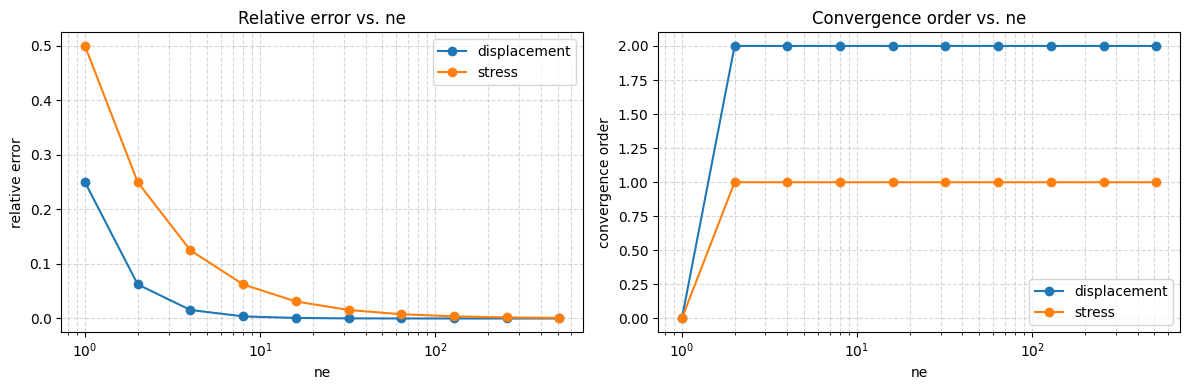

In [40]:
# 演習5：メッシュ生成、解析解、誤差積分、収束表を自分で実装する。
# 必須成果物：5メッシュの表、反力と残差の検証、変位と応力の収束次数。
# TODO: ここに関数と実験コードを書く。
def generate_mesh(L, E_value, A_value, p_value, point_forces_dist, ne=2):
    """
    Return x:(ne+1,), conn:(ne,2), E/A/p:(ne,), point_forces:(ne+1,).
    """
    x = np.linspace(0, L, ne+1)
    conn = np.array([[i, i+1] for i in range(ne)])
    E = np.full(ne, E_value)
    A = np.full(ne, A_value)
    p = np.full(ne, p_value)
    point_forces = np.zeros(ne+1)
    if point_forces_dist:
        for xi, f in point_forces_dist.items():
            point_forces[np.argmin(np.abs(x-xi))] = f
    return x, conn, E, A, p, point_forces
def analytical_u(x, L, E, A, p):
    """
    Return elongation, same shape as x.
    """
    return p/E/A*(L-x/2.)*x
def analytical_stress(x, L, A, p):
    """
    Return stress, same shape as x.
    """
    return p/A*(L-x)
def _computational_u(x, node, conn, u):
    """
    Return uh, same shape as x.
    """
    uh = np.zeros_like(x)
    for i in range(x.shape[0]):
        for j in range(conn.shape[0]):
            xa, xb = node[conn[j]]
            ua, ub = u[conn[j]]
            if x[i] >= xa and x[i] < xb:
                uh[i] = ((xb-x[i])*ua+(x[i]-xa)*ub)/(xb-xa)
    return uh
def _computational_stress(x, node, conn, stress):
    """
    Return stressh, same shape as x.
    """
    stressh = np.zeros_like(x)
    for i in range(x.shape[0]):
        for j in range(conn.shape[0]):
            xa, xb = node[conn[j]]
            if x[i] >= xa and x[i] < xb:
                stressh[i] = stress[j]
                break
    return stressh
def _compute_error(node, conn, fh, f):
    """
    Return eta: float.
    """
    ne = conn.shape[0]
    int_num, int_den = np.zeros((2, ne))
    points, weights = np.polynomial.legendre.leggauss(3)
    for i in range(ne):
        xa, xb = node[conn[i]]
        Jacobian = (xb-xa)/2.
        points_xi = ((1.-points)*xa+(1.+points)*xb)/2.
        int_num[i] = np.sum(weights*(fh(points_xi)-f(points_xi))**2*Jacobian)
        int_den[i] = np.sum(weights*f(points_xi)**2*Jacobian)
    return np.sqrt(np.sum(int_num)/np.sum(int_den))
def evaluate_error(node, conn, u, stress, L, E, A, p):
    """
    Return eta_u: float, eta_sigma: float.
    """
    return _compute_error(
        node, conn,
        lambda x: _computational_u(x, node, conn, u),
        lambda x: analytical_u(x, L, E, A, p),
    ), _compute_error(
        node, conn,
        lambda x: _computational_stress(x, node, conn, stress),
        lambda x: analytical_stress(x, L, A, p),
    ),

L, E_, A_, p_ = 1000., 200000., 100., 2.
point_forces_dist = None
ne, displacement, reaction_force = [], [], []
error = {'displacement_max': [], 'displacement_rel': [], 'stress_rel': []}
convergence = {'displacement': [], 'stress': []}
for i in range(10):
    x, conn, E, A, p, point_forces = generate_mesh(L, E_, A_, p_, point_forces_dist, 2**i)
    K, f = assemble_bar(x, conn, E, A, p, point_forces)
    d, r = solve_dirichlet(K, f, {0: 0.})
    strain, stress, axial_force = recover_bar(x, conn, E, A, d)
    assert np.isclose(np.sum(f+r), 0)
    eta_u, eta_sigma = evaluate_error(x, conn, d, stress, L, E_, A_, p_)
    ne.append(2**i)
    error['displacement_max'].append(float(np.abs(d-analytical_u(x, L, E_, A_, p_)).max()))
    error['displacement_rel'].append(float(eta_u))
    error['stress_rel'].append(float(eta_sigma))
    displacement.append(float(d[-1]))
    reaction_force.append(float(r[0]))
    convergence['displacement'].append(float(np.log2(error['displacement_rel'][-2]/eta_u)) if i != 0 else 0.)
    convergence['stress'].append(float(np.log2(error['stress_rel'][-2]/eta_sigma)) if i != 0 else 0.)
print('ne                              =', ne)
print('error(max displacement) [mm]    =', error['displacement_max'])
print('displacement [mm]               =', displacement)
print('reaction force [N]              =', reaction_force)
print('relative error(displacement)    =', error['displacement_rel'])
print('relative error(stress)          =', error['stress_rel'])
print('convergence order(displacement) =', convergence['displacement'])
print('convergence order(stress)       =', convergence['stress'])

import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ne, error['displacement_rel'], 'o-', label='displacement')
ax1.plot(ne, error['stress_rel'], 'o-', label='stress')
ax1.set_xscale('log')
ax1.set_xlabel('ne')
ax1.set_ylabel('relative error')
ax1.grid(True, which='both', ls='--', alpha=0.5)
ax1.legend()
ax1.set_title('Relative error vs. ne')

# disp_conv_mean = np.array(convergence['displacement'][1:]).mean()
# stress_conv_mean = np.array(convergence['stress'][1:]).mean()
ax2.plot(ne, convergence['displacement'], 'o-', label='displacement')
ax2.plot(ne, convergence['stress'], 'o-', label='stress')
# ax2.axhline(disp_conv_mean, color='C0', linestyle='--', linewidth=1.5, alpha=0.8,
#       label=f'avg displacement ({disp_conv_mean:.2f})')
# ax2.axhline(stress_conv_mean, color='C1', linestyle='--', linewidth=1.5, alpha=0.8,
#       label=f'avg stress ({stress_conv_mean:.2f})')
ax2.set_xlabel('ne')
ax2.set_ylabel('convergence order')
ax2.set_xscale('log')
ax2.grid(True, which='both', ls='--', alpha=0.5)
ax2.legend()
ax2.set_title('Convergence order vs. ne')

plt.tight_layout()
plt.show()

## 演習6 — 出力を根拠とともに説明する（5点）

実務データは不要。演習5の自作ソルバをCAEの最小例として答える。

1. 入力から出力まで、K・f・d・B・応力がどこで作られるか説明する（2点）。
2. 「反力が合ったので応力も正確」「積分点を増やせば粗いメッシュでも変位場が正確」の2主張を、演習結果で評価する（2点）。
3. このソルバを落錘や座屈へそのまま使えない理由を一つ示す（1点）。

### あなたの回答

1.
- K: 節点座標と接続表、要素ごとの縦弾性係数、断面積の入力から作られる
- f: 節点座標と接続表、分布荷重、集中節点荷重の入力から作られる
- d: Kおよびfの計算後、それらの結果と指定変位の入力から作られる
- B: 節点座標と接続表の入力から作られる
- 応力: dおよびBの計算後に計算されるひずみと要素ごとの縦弾性係数の入力から作られる
2.
- 演習5の結果より、いずれの要素数でも反力は解析解に一致しているが、応力誤差はメッシュ細分化に伴い低減しており、要素数16においても応力は収束していない。したがって、「反力が合ったので応力も正確」とは言えない。
- 演習2の結果より、積分点を増やすことで要素剛性行列および等価節点荷重ベクトルは誤差が低減するため、剛性行列および節点荷重ベクトルの正確性が向上し、結果として節点変位の正確性は向上すると考えられる。一方で、積分点を増やしても要素内の変位分布が線形であることは不変である(形状関数により決められている)ため、変位場全体が正確とは言い切れない。実際に演習5の結果より、メッシュの細分化による変位誤差の相対$L^2$ノルムの低減が確認されており、要素数8以下では変位場が収束していない。したがって、「積分点を増やせば粗いメッシュでも変位場が正確」とは言えない。
3.落錘の再現では衝撃荷重を印加する必要があるために動的解析が必要になるほか、降伏による大変形を考慮するための材料非線形および幾何学的非線形、部材とインパクタの接触を考慮するための接触非線形を取り入れる必要がある。また、座屈の再現でも荷重経路を追跡するために動的解析が必要になるほか、大変形を考慮するための幾何学的非線形を取り入れる必要がある。

## 任意発展

一様棒の内部節点へ集中荷重を追加し、左右の軸力の跳びと節点釣合いを検証する。問題設定、荷重符号、解析解、テスト条件を自分で定める。Phase 4の提出必須条件には含めない。


In [ ]:
# 任意発展：設定、解析解、検証コード


## 振り返り

- 導出と実装がつながった箇所：
- 設計判断の自由度とヒント量は適切だったか：
- 疑問・教材の改善案：
- 計算と予想の不一致（あった場合のみ）：

回答はこのNotebookに残してください。採点時に [学習ログ](../docs/learning-log.md)へ要点と改善判断を記録します。
